In [3]:
import os
os.chdir('..')  
print(os.getcwd())  

c:\Users\zkx14\Desktop\testing


In [4]:
import json
from pathlib import Path

base = Path("panoramic-dental-x-rays-DatasetNinja")

# check the first annotation JSON and print what it looks like
first_ann = base / "Segmentation1" / "ann" / "1.png.json"

with open(first_ann) as f:
    ann = json.load(f)

print(json.dumps(ann, indent=2))

{
  "description": "",
  "tags": [],
  "size": {
    "height": 1300,
    "width": 3100
  },
  "objects": [
    {
      "id": 40606847,
      "classId": 53055,
      "description": "",
      "geometryType": "bitmap",
      "labelerLogin": "ea@datasetninja.com",
      "createdAt": "2023-09-14T10:03:12.074Z",
      "updatedAt": "2023-09-14T10:03:12.074Z",
      "tags": [],
      "classTitle": "mandible",
      "bitmap": {
        "data": "eJx1d3kgVO/3PwYXcalsMddatijJNpfsW7JliRZL2UsMrj0xJvsSSUgYS2glFCHNRBGlQQsRE2GEDKls8b183p/lj99v/rjPec55nfU5c59zk22sTHm4RLiYmJh4jpoZ2TIxcQswMbH+YcagHHUmrSR0YbexsDdG183NzduDxV9QihmxtbJj0psc8GJiktt/1EjfPvzWXKHltfGmIBOHH/pRNA4LaMGFNexcpEZRJNBu1cLfr8XYpbz0Jo3xbVXW/+kxhcdmXBIEozhxjsveSDUXS16EEQun7fehdI/FBjpGouF5KW/s8AZzNNO3j2UoxZ6qw6KSRpeWKAajWb8FG4hTJlaW1zFRTJtpUCu7js4mL3yZd4PjPfnqO2v68pHf0jZsz7FO35bbijt7Z2hTU1NJ2BhyUYIDo5tgmMGrw3OPfMlAqFIcwYfFnsm/FHsw3oEajTJ0ybkvFJYnmJ6qrBCe8X/U3+RU4rt87mB8CGOCPJagMXDsLHQJJ1zSVmcmSgOdyqNx+IGvSv7L8LL5iyvQ5XYeV+B5EGow1roNXg5i2iYU

In [5]:
import json
import cv2
import numpy as np
import zlib
import base64
from pathlib import Path

# =========================================================
# Supervisely annotation -> segmentation mask conversion
# =========================================================
# This code turns Supervisely bitmap annotations from the
# panoramic dental X-ray dataset into simple binary masks.
#
# What it does:
# 1. reads the annotation JSONs
# 2. decodes the bitmaps
# 3. pastes them into full-size masks
# 4. merges mandible regions if needed
# 5. saves the masks as PNGs
# 6. saves the image-mask pairs for training later
#
# These masks are what a segmentation model will learn from.
# =========================================================

# ---------------------------------------------------------
# Bitmap decoder
# ---------------------------------------------------------
# Supervisely stores masks as compressed bitmap patches
# encoded with Base64 + zlib.
#
# This function:
# - decodes the compressed bitmap
# - rebuilds the annotation patch
# - pastes it into the right spot in the full-size mask
# ---------------------------------------------------------
def decode_bitmap(data, origin, img_h, img_w):

    compressed = base64.b64decode(data)

    decompressed = zlib.decompress(compressed)

    arr = np.frombuffer(decompressed, dtype=np.uint8)

    bitmap_img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    # Create full-size empty mask
    mask = np.zeros((img_h, img_w), dtype=np.uint8)

    # Bitmap placement coordinates
    x0, y0 = origin[0], origin[1]

    h, w = bitmap_img.shape[:2]

    # Prevent out-of-bound indexing
    x1 = min(x0 + w, img_w)
    y1 = min(y0 + h, img_h)

    # Insert bitmap patch into mask
    mask[y0:y1, x0:x1] = bitmap_img[:y1-y0, :x1-x0]

    return mask


# Annotation -> mask conversion
# Turns one Supervisely annotation JSON into a binary mandible mask.
# If there are several mandible patches, merge them into one mask.

def convert_ann_to_mask(ann_path, img_path, out_mask_dir):

    # Load the image and annotation
    img = cv2.imread(str(img_path))

    if img is None:
        print(f"Could not read: {img_path}")
        return None

    # Load annotation JSON
    with open(ann_path) as f:
        ann = json.load(f)

    # Get original image dimensions
    img_h = ann['size']['height']
    img_w = ann['size']['width']

    # Initialize empty segmentation mask
    mask = np.zeros((img_h, img_w), dtype=np.uint8)

    # Process annotated objects
    for obj in ann.get('objects', []):

        # Only use mandible annotations
        if obj['classTitle'] == 'mandible' and 'bitmap' in obj:

            patch = decode_bitmap(
                obj['bitmap']['data'],
                obj['bitmap']['origin'],
                img_h,
                img_w
            )

            # Merge mask regions together
            mask = np.maximum(mask, patch)

    # Output mask filename
    out_path = Path(out_mask_dir) / (
        Path(ann_path).stem.replace('.png', '') + '_mask.png'
    )

    # Save generated mask
    cv2.imwrite(str(out_path), mask)

    return out_path

# Dataset Conversion Pipeline
# Iterate through all dataset splits, converts annotation
# files into segmentation masks, and stores image-mask pairs
# for downstream deep learning training.

# build masks for all annotation files in both splits
base = Path("panoramic-dental-x-rays-DatasetNinja")
out_mask_dir = Path("masks")
out_mask_dir.mkdir(exist_ok=True)

# Store final dataset paths
img_paths_all = []
mask_paths_all = []

# Splitting dataset into Segmentation1 and Segmentation2
for split in ["Segmentation1", "Segmentation2"]:

    ann_dir = base / split / "ann"
    img_dir = base / split / "img"

    # Iterate through annotation files
    for ann_file in sorted(ann_dir.glob("*.json")):

        # Match annotation with image
        img_name = ann_file.stem
        img_file = img_dir / img_name

        # Skip missing images
        if not img_file.exists():
            print(f"Image not found: {img_file}")
            continue

        # Generate segmentation mask
        mask_path = convert_ann_to_mask(
            ann_file,
            img_file,
            out_mask_dir
        )

        # Store valid image-mask pairs
        if mask_path:
            img_paths_all.append(img_file)
            mask_paths_all.append(mask_path)

# Summary
print(f"Total pairs ready: {len(img_paths_all)}")

Total pairs ready: 232


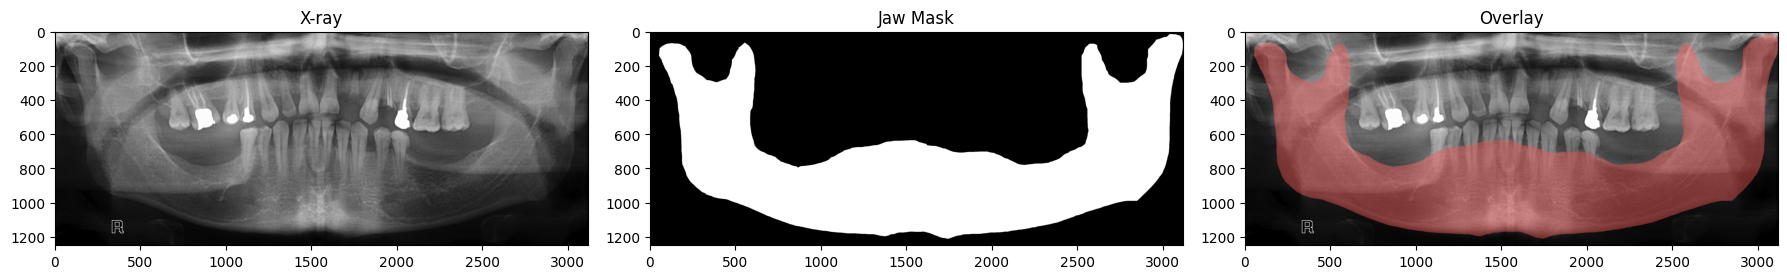

In [6]:
import matplotlib.pyplot as plt
import cv2

# =========================================================
# Segmentation mask visualization & sanity check
# =========================================================
# Quick visual check to make sure the generated masks line up
# with the original panoramic dental X-ray.
#
# Shows:
# 1. the original X-ray
# 2. the binary mandible mask
# 3. the mask overlaid on the image

idx = 5 # Selecting sample index for visualization 

# Load Image & Mask
img = cv2.imread(str(img_paths_all[idx]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(str(mask_paths_all[idx]), 0)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original X-ray
axes[0].imshow(img, cmap='gray')
axes[0].set_title('X-ray')

# Segmentation mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Jaw Mask')

# Overlay Mask on Image

# tint the mandible area red so it is easy to spot on the image
overlay = img.copy()

overlay[mask > 0] = [255, 80, 80]

blended = cv2.addWeighted(
    img,
    0.6,
    overlay,
    0.4,
    0
)

axes[2].imshow(blended)
axes[2].set_title('Overlay')

# Display
plt.tight_layout()
plt.show()

In [7]:
import json

with open('splits.json', 'w') as f:
    json.dump({
        'images': [str(p) for p in img_paths_all],
        'masks':  [str(p) for p in mask_paths_all]
    }, f)

print(f'Saved {len(img_paths_all)} image-mask pairs to splits.json')

Saved 232 image-mask pairs to splits.json
